## IMPORT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import lightgbm as lgb
import seaborn as sns
import joblib as jbl
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

## PRE PROCESSING

### ANALYSE DATASET

In [2]:
df = pd.read_parquet("US_accidents_dataset.parquet")

print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng End_Lat End_Lng  Distance(mi)  ... Roundabout Station  \
0  39.865147 -84.058723     NaN     NaN          0.01  ...      False   False   
1  39.928059 -82.831184     NaN     NaN          0.01  ...      False   False   
2  39.063148 -84.032608     NaN     NaN          0.01  ...      False   False   
3  39.747753 -84.205582     NaN     NaN          0.01  ...      False   False   
4  39.627781 -84.188354     NaN     NaN          0.01  ...      False   False   

    Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0  False       

In [4]:
df.isna().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

### DROP REDUNDANT VARIABLES

In [5]:
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code",'Wind_Chill(F)', 'Country', 'ID'], inplace=True)

### CREATE NEW VARIABLES FROM START/END TIME

In [6]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)

### ANALYSING DURATION MIN

In [7]:
print(df['duration_min'].describe())
print(f"Valori > 1 giorno: {(df['duration_min'] > 1440).sum()}")
print(f"Valori > 1 settimana: {(df['duration_min'] > 10080).sum()}")

count    7.728394e+06
mean     4.444210e+02
std      1.351229e+04
min      1.216667e+00
25%      3.150000e+01
50%      7.483333e+01
75%      1.251500e+02
max      2.812939e+06
Name: duration_min, dtype: float64
Valori > 1 giorno: 34981
Valori > 1 settimana: 6824


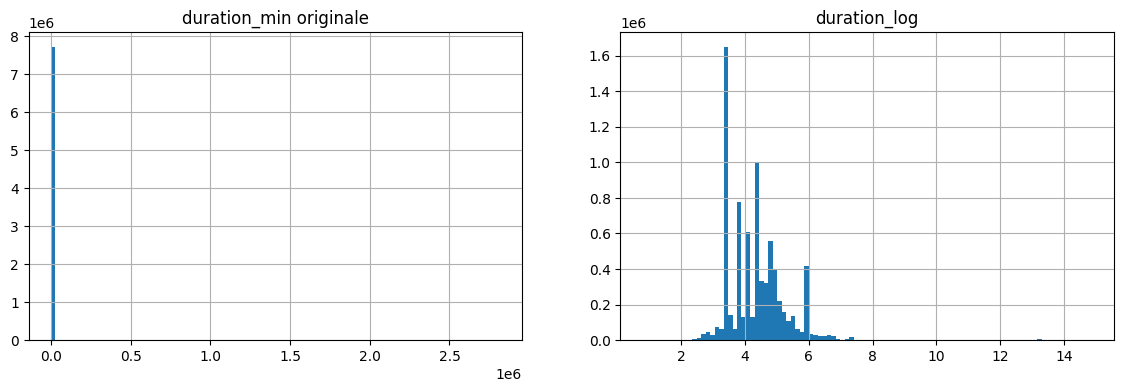

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['duration_min'].hist(bins=100, ax=axes[0])
axes[0].set_title('duration_min originale')
np.log1p(df['duration_min']).hist(bins=100, ax=axes[1])
axes[1].set_title('duration_log')
plt.show()

### NEW VARIABLES FROM WEATHER CONDITIONS

In [9]:
def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

### ANALYSING STREETS

In [10]:
print(df['Street'].value_counts().head(50))
def extract_suffix(name):
    if pd.isna(name):
        return 'Unknown'
    tokens = str(name).upper().split()
    return tokens[-1] if tokens else 'Unknown'

print(df['Street'].apply(extract_suffix).value_counts().head(30))

Street
I-95 N                78430
I-95 S                74528
I-5 N                 71968
I-10 E                55572
I-10 W                53725
I-5 S                 51781
I-80 W                39662
I-80 E                36113
I-405 N               32364
I-75 N                28166
I-75 S                27546
I-90 E                26426
I-15 N                24470
I-94 W                24003
I-90 W                23279
US-101 N              20041
I-95                  20028
I-94 E                19940
I-70 E                19697
I-15 S                19230
I-40 W                19034
I-84 E                18955
I-35 N                18761
I-405 S               18318
I-40 E                17800
CA-99 N               17651
I-70 W                17402
I-84 W                17311
I-64 E                16611
I-64 W                16072
CA-60 W               15305
I-35 S                15268
CA-99 S               15261
Golden State Fwy S    14869
I-20 W                14453
I-10         

### CLASSIFY STREETS

In [11]:
def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

In [12]:
print(df['Street_Type'].value_counts())

Street_Type
Interstate            1924958
Road                  1199935
Street                 698172
Avenue                 651379
Freeway_Expressway     610871
Highway                564635
State_Route            490991
Boulevard              343631
Drive                  320039
Other                  289494
US_Route               209798
Parkway                192609
Local                   96530
Lane                    88500
Trail                   35983
Unknown                 10869
Name: count, dtype: int64


### FINDING MOST USED WORDS IN DESCRIPTION

In [13]:
print(df['Description'].sample(50, random_state=42).tolist())
print(df['Description'].value_counts().head(20))

['At Haverhill Rd - Earlier accident.', 'Incident on STANFORD RANCH RD near HOUSE 6750 Drive with caution.', 'Accident on GA-140 Holcomb Bridge Rd Westbound at Barnwell Rd.', 'Left lane blocked due to accident on I-5 Northbound near Berkeley St.', 'Right lane closed due to accident on AZ-101-LOOP Southbound at Exit 50 Mckellips Rd.', 'Slow traffic and left hand shoulder blocked due to accident on US-20 Eastbound between Exit 140 IA-17 Exit 140 and Exit 145 CR-R38 Neely Ave.', 'Stationary traffic on I-495 N from VA-650/Gallows Rd/Exit 7 (Capital Beltway/I-495) to I-66/Exit 9 (Capital Beltway/I-495) due to accident.', 'Lane blocked due to accident on I-16 Westbound after Exit 78 US-221.', 'Lane blocked due to accident on MD-198 Spencerville Rd near Santini Rd.', 'Accident on Nimitz Fwy N - I-880 N from Tennyson Rd (I-880) to CA-92/Jackson St (I-880).', 'At MN-95/Exit 147 - Accident.', 'Restrictions due to accident on Buttermilk Hollow Rd at Thompson Run Rd.', 'Incident on CANCHA DE GOLF 

### BOOLEAN VARIABLES FROM DESCRIPTION

In [14]:
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

### CONVERTING BOOLEAN VARIABLES TO INT

In [15]:
bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

### CORRELATION BETWEEN TWILIGTH AND TIME OF THE DAY

In [18]:
cols = ['Sunrise_Sunset',
        'Civil_Twilight',
        'Nautical_Twilight',
        'Astronomical_Twilight']

df[[c + '_num' for c in cols]] = (df[cols] == 'Day').astype(int)

light_cols_num = [c + '_num' for c in cols] + ['time_of_day']
print(df[light_cols_num].corr().round(2))

print("\nSunrise_Sunset vs time_of_day:")
print(pd.crosstab(df['time_of_day'],
                  df['Sunrise_Sunset'], normalize='index').round(2))

                           Sunrise_Sunset_num  Civil_Twilight_num  \
Sunrise_Sunset_num                       1.00                0.89   
Civil_Twilight_num                       0.89                1.00   
Nautical_Twilight_num                    0.78                0.87   
Astronomical_Twilight_num                0.68                0.77   
time_of_day                             -0.62               -0.68   

                           Nautical_Twilight_num  Astronomical_Twilight_num  \
Sunrise_Sunset_num                          0.78                       0.68   
Civil_Twilight_num                          0.87                       0.77   
Nautical_Twilight_num                       1.00                       0.88   
Astronomical_Twilight_num                   0.88                       1.00   
time_of_day                                -0.71                      -0.69   

                           time_of_day  
Sunrise_Sunset_num               -0.62  
Civil_Twilight_num          

In [19]:
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

### CIRCULAR ENCODING OF WIND DIRECTION

In [20]:
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

### VARIABLE SOURCE TO CATEGORY

In [21]:
source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

### DROP VARIABLES THAT CAUSE NOISE

In [22]:
df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

### LOGARITMIC TRANSFORM

In [26]:
num_cols = ['duration_min', 'desc_length', 'Distance(mi)',
            'Wind_Speed(mph)', 'Precipitation(in)']

# soluzione “pandas”: calcola la skewness di tutte le colonne in un colpo
print(df[num_cols].skew().round(2))

duration_min         50.64
desc_length           1.33
Distance(mi)         20.39
Wind_Speed(mph)       8.05
Precipitation(in)    86.00
dtype: float64


In [27]:
cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

In [28]:
log_cols = [c for c in df.columns if c.endswith('_log')]
for col in log_cols:
    print(f"{col:30} skewness: {df[col].skew():.2f}")

duration_min_log               skewness: 1.33
Distance(mi)_log               skewness: 1.61
Wind_Speed(mph)_log            skewness: -1.17
desc_length_log                skewness: -0.09


### RAIN TO BOOLEAN

In [ ]:
df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
df.drop(columns=['Precipitation(in)'], inplace=True)

### ANALYSING SEVERITY

In [30]:
print(df['Severity'].value_counts(normalize=True))

Severity
2    0.796670
3    0.168125
4    0.026488
1    0.008717
Name: proportion, dtype: float64


### CLUSTER ANALYSIS

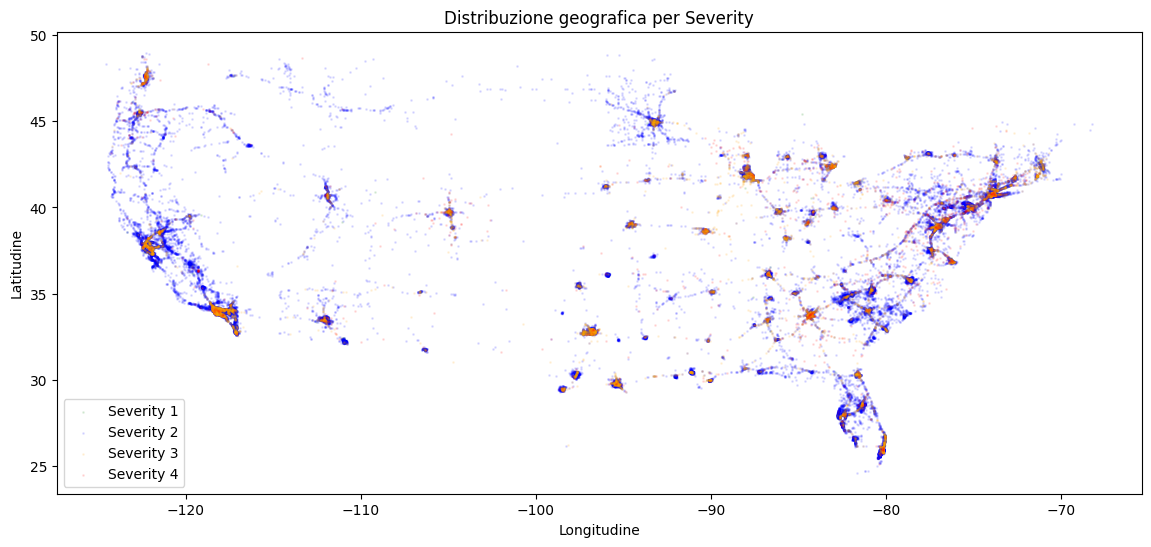

K=5 → inertia: 2078622
K=10 → inertia: 721003
K=15 → inertia: 403704
K=20 → inertia: 250754
K=25 → inertia: 187028


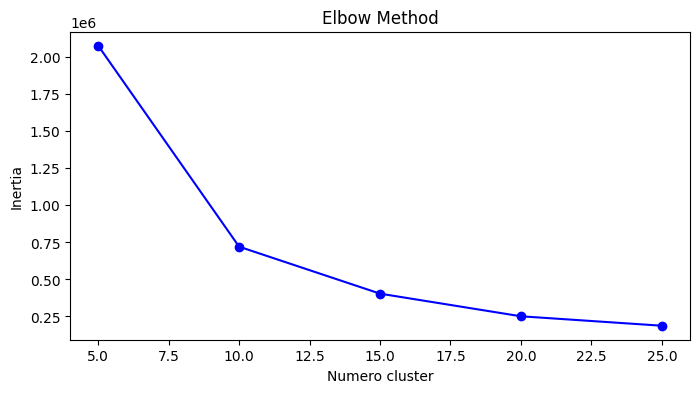

In [31]:
plt.figure(figsize=(14, 6))
colors = {1: 'green', 2: 'blue', 3: 'orange', 4: 'red'}
sample = df.sample(50000, random_state=42)

for sev in [1, 2, 3, 4]:
    mask = sample['Severity'] == sev
    plt.scatter(sample[mask]['Start_Lng'], 
                sample[mask]['Start_Lat'],
                c=colors[sev], label=f'Severity {sev}',
                alpha=0.1, s=1)

plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.title('Distribuzione geografica per Severity')
plt.legend()
plt.show()

inertias = []
K_range = range(5, 30, 5)

sample_coords = df[['Start_Lat', 'Start_Lng']].sample(100000, random_state=42)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_coords)
    inertias.append(km.inertia_)
    print(f"K={k} → inertia: {km.inertia_:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Numero cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## TRAIN, VALIDATION, TEST SPLIT

In [32]:
X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (4946172, 45)
Val:   (1236543, 45)
Test:  (1545679, 45)


### K-MEANS CLUSTERS

Severity         1      2      3      4
Geo_Cluster                            
0            0.008  0.856  0.121  0.015
1            0.002  0.809  0.180  0.009
2            0.009  0.800  0.176  0.016
3            0.006  0.773  0.173  0.047
4            0.012  0.802  0.154  0.031
5            0.002  0.796  0.181  0.021
6            0.007  0.831  0.128  0.034
7            0.010  0.672  0.275  0.042
8            0.012  0.859  0.122  0.008
9            0.025  0.779  0.157  0.039


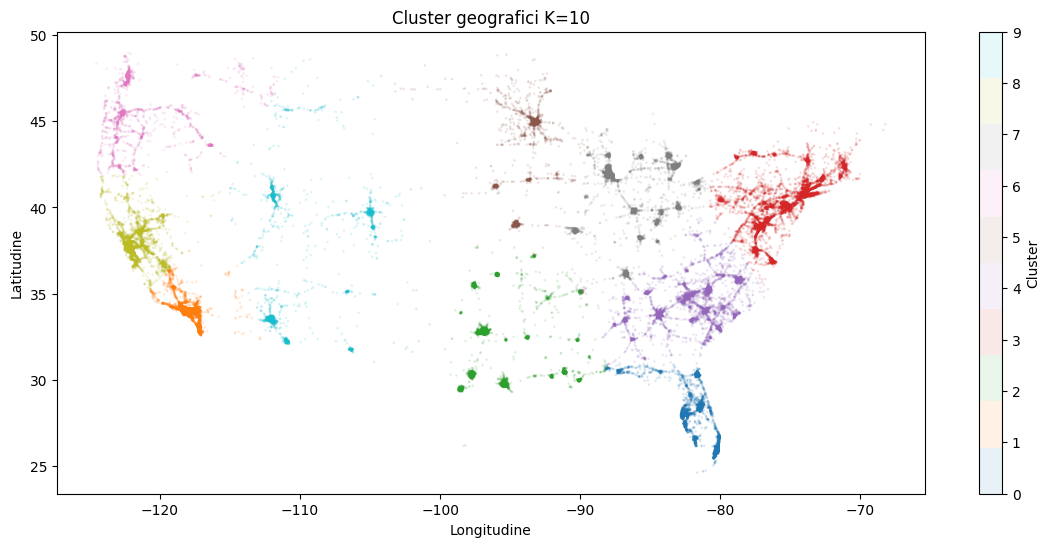

In [ ]:
km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train[['Start_Lat', 'Start_Lng']].sample(200000, random_state=42))

df = df.copy() 
df['Geo_Cluster'] = km.predict(df[['Start_Lat', 'Start_Lng']])

print(df.groupby('Geo_Cluster')['Severity']
         .value_counts(normalize=True)
         .unstack()
         .round(3))

plt.figure(figsize=(14, 6))
sample = df.sample(50000, random_state=42)
scatter = plt.scatter(sample['Start_Lng'], sample['Start_Lat'],
                      c=sample['Geo_Cluster'], cmap='tab10',
                      alpha=0.1, s=1)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.title('Cluster geografici K=10')
plt.show()

In [34]:
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['Geo_Cluster'] = km.predict(X_train[['Start_Lat', 'Start_Lng']])
X_val['Geo_Cluster']   = km.predict(X_val[['Start_Lat', 'Start_Lng']])
X_test['Geo_Cluster']  = km.predict(X_test[['Start_Lat', 'Start_Lng']])

### CATEGORICAL FEATURES

In [36]:
for col in ['Weather_Group', 'Street_Type', 'Source', 'Geo_Cluster']:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

### FREQUENCY FEATURES

In [37]:
for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq         = X_train[col].value_counts()
        X_train[col] = X_train[col].map(freq)
        X_val[col]   = X_val[col].map(freq).fillna(0)
        X_test[col]  = X_test[col].map(freq).fillna(0)

### STARTING WEIGHTS

In [38]:
base_weights          = compute_sample_weight(class_weight='balanced', y=y_train)
sample_weights_custom = base_weights.copy()
mask_class0           = (y_train == 0).values
mask_class2           = (y_train == 2).values
mask_class3           = (y_train == 3).values
sample_weights_custom[mask_class0] *= 0.065
sample_weights_custom[mask_class2] *= 0.45
sample_weights_custom[mask_class3] *= 0.15

for cls in range(4):
    mask = (y_train == cls).values
    print(f"Classe {cls} (Severity {cls+1}): peso medio = {sample_weights_custom[mask].mean():.3f}")

Classe 0 (Severity 1): peso medio = 1.864
Classe 1 (Severity 2): peso medio = 0.314
Classe 2 (Severity 3): peso medio = 0.669
Classe 3 (Severity 4): peso medio = 1.416


## MODEL

### PARAMETERS

In [ ]:
LEARNING_RATE    = 0.01
NUM_LEAVES       = 255
RANDOM_STATE     = 42
SUBSAMPLE        = 0.8
COLSAMPLE_BYTREE = 0.8
REG_ALPHA        = 0.1
REG_LAMBDA       = 0.1

### MODEL

In [ ]:
model = lgb.LGBMClassifier(
    n_estimators=20000,
    learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES,
    min_child_samples=50,
    min_child_weight=1e-3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    device='gpu',
    gpu_platform_id=1,
    gpu_device_id=0,
    objective='multiclass',
    num_class=4,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    reg_alpha=REG_ALPHA,
    reg_lambda=REG_LAMBDA
)

### TRAINING

In [ ]:
model.fit(
    X_train, y_train,
    sample_weight=sample_weights_custom,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ],
    categorical_feature=['Weather_Group', 'Street_Type', 'Source', 'Geo_Cluster']
)

### LOAD MODEL AND PROBABILITIES

In [41]:
model = jbl.load('lgbm_model_final.pkl')
test_probs = jbl.load('lgb_test_probs.pkl')

print(f"lgb_test_probs shape: {test_probs.shape}")

lgb_test_probs shape: (1545679, 4)


## EVALUATION

In [45]:
test_probs = np.argmax(test_probs, axis=1)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Severity 1       0.75      0.63      0.68     13473
  Severity 2       0.97      0.95      0.96   1231396
  Severity 3       0.85      0.90      0.88    259868
  Severity 4       0.65      0.75      0.70     40942

    accuracy                           0.94   1545679
   macro avg       0.80      0.81      0.80   1545679
weighted avg       0.94      0.94      0.94   1545679



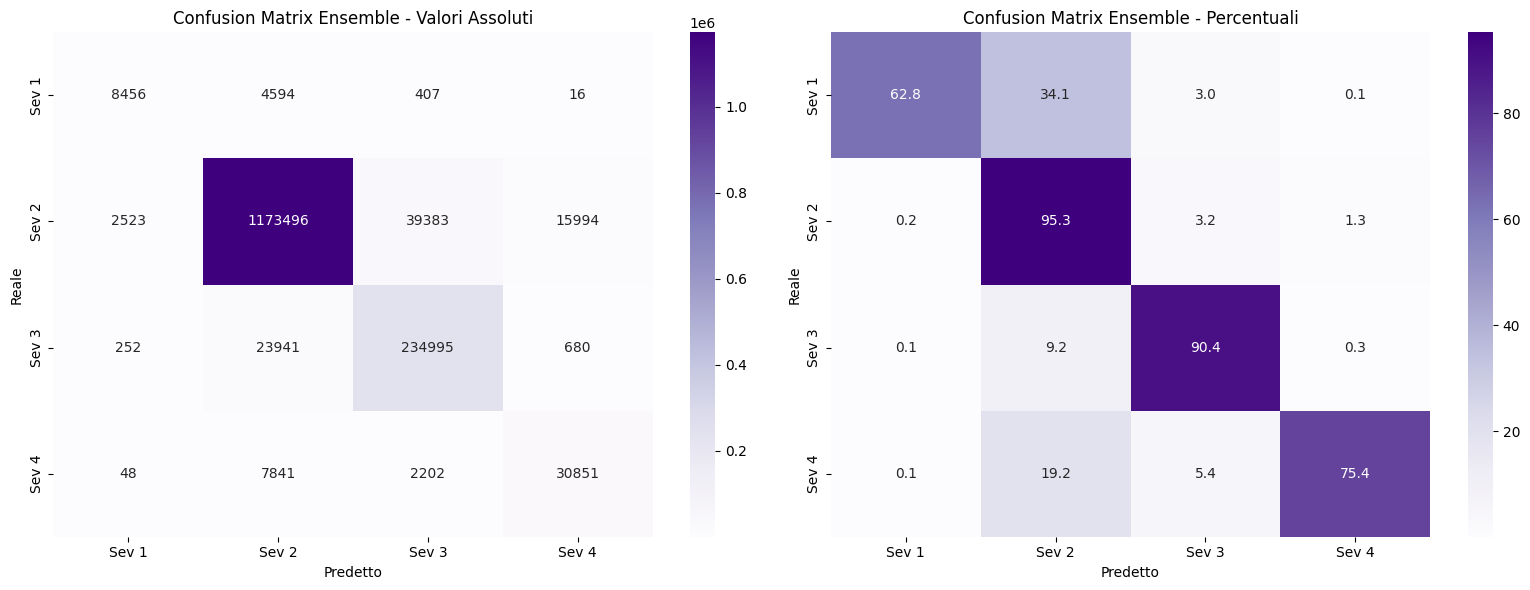


TOP 20 FEATURE IMPORTANCE
                  feature  importance
             Pressure(in)     1407136
Astronomical_Twilight_num     1377786
                Wind_Calm     1374700
                  Zipcode     1232063
           Temperature(F)     1225458
              Humidity(%)     1220019
                Start_Lat     1092847
                Start_Lng     1012589
                     City      969466
                 Wind_Cos      865367
                 Wind_Sin      810779
                   County      790463
       Civil_Twilight_num      468531
                month_cos      422199
       Sunrise_Sunset_num      420700
        is_holiday_period      396416
                    State      377784
                month_sin      330174
              Street_Type      289317
           Visibility(mi)      239441


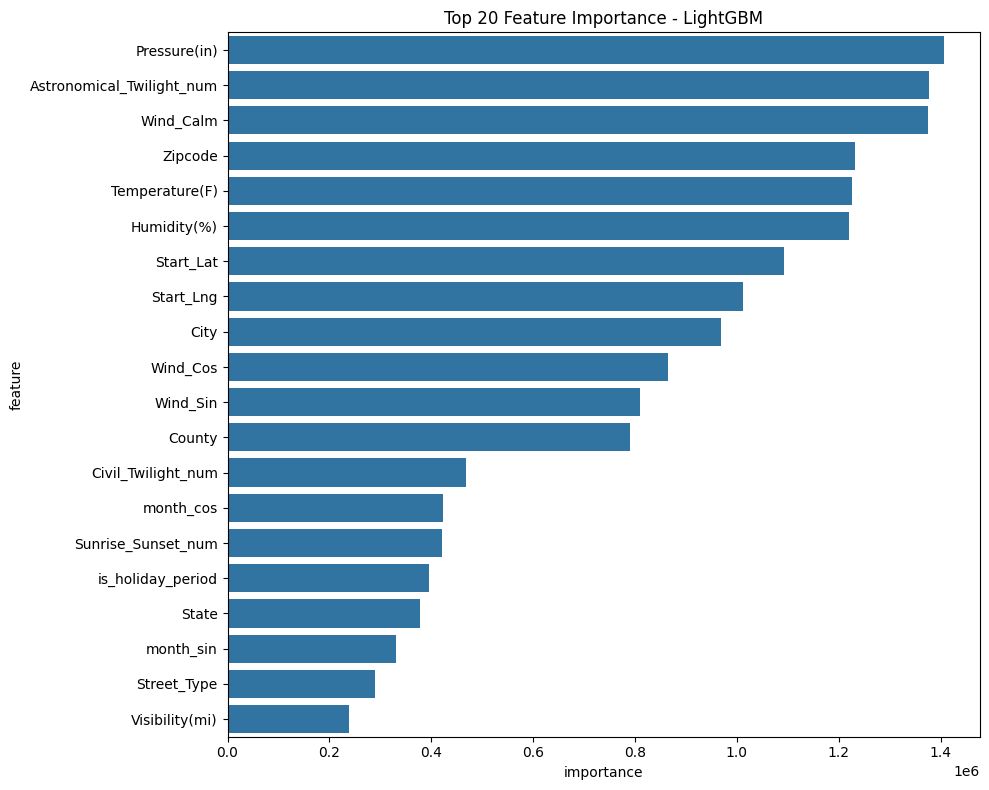

In [47]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, test_probs,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))

cm         = confusion_matrix(y_test, test_probs)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix Ensemble - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix Ensemble - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

# Feature Importance
print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)
imp = model.feature_importances_
cols = list(X_test.columns)[: len(imp)]      
feat_imp = pd.DataFrame({'feature': cols, 'importance': imp}) \
            .sort_values('importance', ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()